# <a id='toc1_'></a>[Topic 20 - Nyquist Analysis](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Topic 20 - Nyquist Analysis](#toc1_)    
    - [repeat with a gain of 1/3](#toc1_1_1_)    
  - [Example 20-4](#toc1_2_)    
  - [Side by Side Nyquist](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [188]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)


Found break-in/out at K =  1.794
At possible locations s = -6.472, -6.472

Found break-in/out at K =  0.006
At possible locations s =  2.472,  2.472


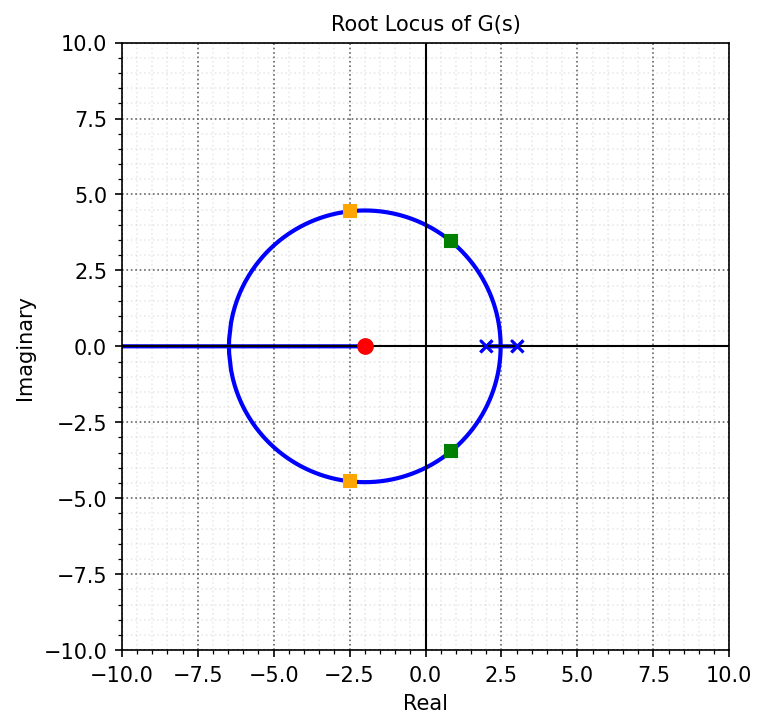

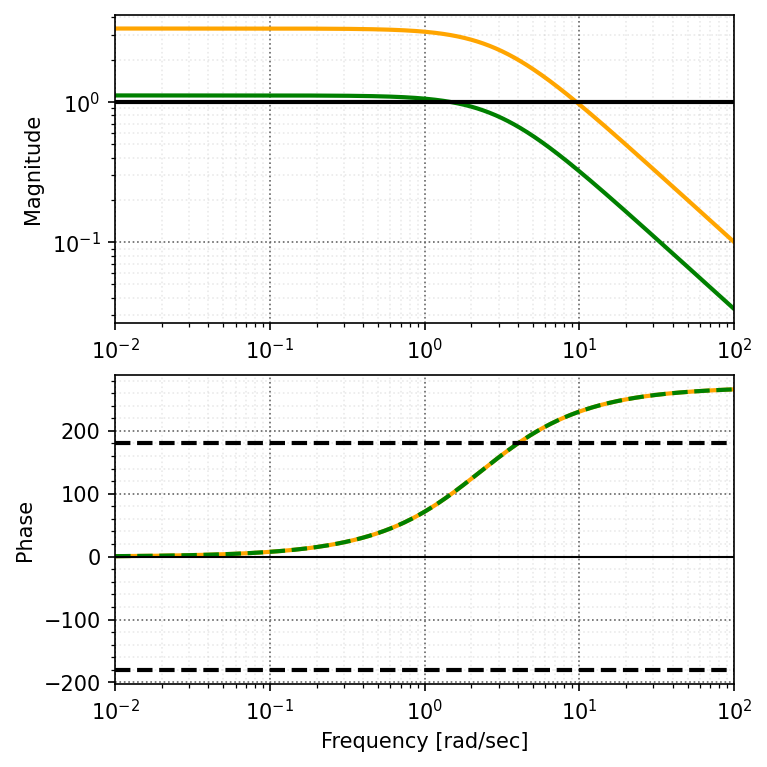

In [206]:
G = 10*ct.tf((1,2),(1,-2))*ct.tf(1,(1,-3))
gain_high=1
gain_low=1/3
Gcl_gain_high = ct.feedback(G*gain_high,1)
Gcl_gain_low = ct.feedback(G*gain_low,1)

fig2, ax = plt.subplots(num=11, nrows=1, ncols=1, figsize=(5, 5),dpi=150,constrained_layout = True)
try:
    rl =  ct.rlocus(G, gains=cm.Root_Locus_gains(G), color='b', ax=ax)
except:
    rl =  ct.rlocus(G, gains=cm.Root_Locus_gains(G), ax=ax)
ax.set_aspect('equal')
ax.set_xlim([-10, 10]);ax.set_ylim([-10, 10])
ax.set_xlabel("Real Axis")
ax.set_ylabel("Imaginary Axis")
bm.nicegrid(ax)
cm.new_pzmap(G, ax=ax,title="Root Locus of G(s)")
plt.plot(Gcl_gain_high.poles().real,Gcl_gain_high.poles().imag,color='orange',marker='s',linestyle='None')
plt.plot(Gcl_gain_low.poles().real,Gcl_gain_low.poles().imag,color='green',marker='s',linestyle='None')
plt.savefig("./figs/L20_fig1.pdf", dpi=300)
plt.show()

# Frequency Response Plot
w = np.logspace(-2,2,1000)
Gf = G(complex(0,1)*w)
fig, ax = plt.subplots(2,1,figsize=(5, 5),dpi=150,constrained_layout = True)
ax[0].loglog(w,np.abs(Gf)*gain_high,'orange')
ax[0].loglog(w,np.abs(Gf)*gain_low,'green')
ax[1].semilogx(w,np.unwrap(np.angle(Gf))*cm.r2d,'orange')
ax[1].semilogx(w,np.unwrap(np.angle(Gf))*cm.r2d,'green',ls='--')
ax[0].axhline(y=1,ls='-',c='k')
ax[1].axhline(y=-180,ls='--',c='k')
ax[1].axhline(y=180,ls='--',c='k')
bm.nicegrid(ax)
ax[0].set_ylabel("Magnitude")
ax[1].set_ylabel("Phase")
ax[1].set_xlabel("Frequency [rad/sec]")
plt.savefig("./figs/L20_fig2.pdf", dpi=300)



### <a id='toc1_1_1_'></a>[repeat with a gain of 1/3](#toc0_)

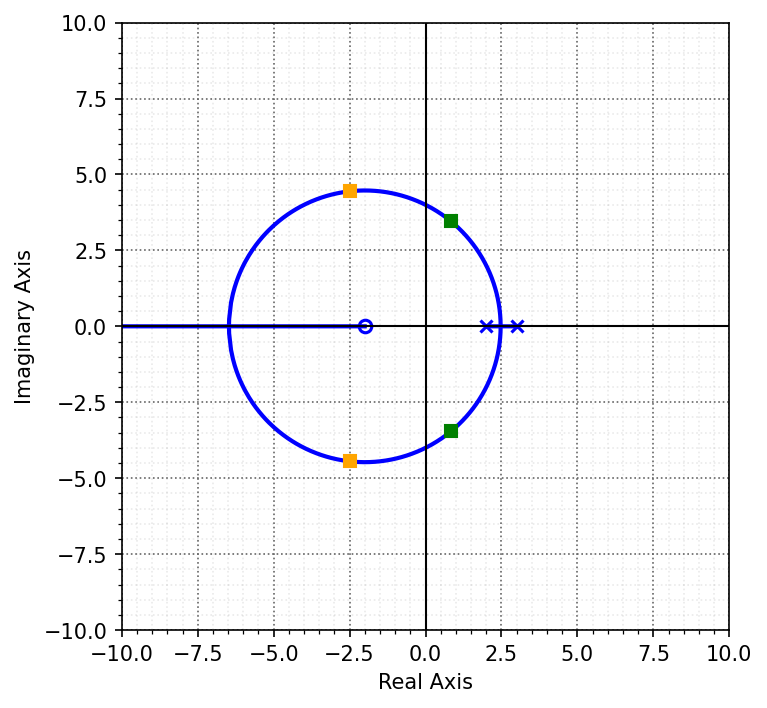

In [ ]:
axs = fig2.get_axes()
axs[0].plot(Gcl_gain_low.poles().real,Gcl_gain_low.poles().imag,c='green',marker='s',linestyle='None')
fig2.savefig("./figs/L20_fig1a.pdf", dpi=300)
fig2

In [191]:
def add_arrows_to_line(ax, x, y, n_arrows=3, arrowstyle='->', color=None, arrowsize=10):
    if color is None:
        color = ax.get_lines()[-1].get_color()
    idxs = pick_arrow_indices(len(x), n_arrows, margin_frac=0.4)
    for idx in idxs:
        start = (x[idx], y[idx])
        end   = (x[idx+1], y[idx+1])
        ax.annotate(
            '',
            xy=end,
            xytext=start,
            arrowprops=dict(
                arrowstyle=arrowstyle,
                color=color,
                shrinkA=0,
                shrinkB=0,
                linewidth=1.5,
                mutation_scale=arrowsize
            )
        )

def pick_arrow_indices(N, n_arrows, margin_frac=0.1):
    """
    Pick indices for arrows over a curve of length N.
    Parameters
    ----------
    N : int
        Total number of points in the curve.
    n_arrows : int
        How many arrow positions you want.
    margin_frac : float
        Fraction of endpoints to skip (default 10%).

    Returns
    -------
    idxs : ndarray of ints
        Indices into array of length N where arrows should go.
    """
    if n_arrows <= 0 or N < 2:
        return np.array([], dtype=int)

    # how many points to skip at each end
    margin = int(np.round(margin_frac * N))

    # ensure margin doesn’t exceed half the data
    margin = min(margin, N // 2 - 1)

    # workable region
    start = margin
    end = N - margin

    if end <= start:
        # fall back to simple spacing
        return np.linspace(0, N - 1, n_arrows, dtype=int)

    # pick even indices in the central region
    idxs = np.linspace(start, end - 1, n_arrows, dtype=int)
    return idxs

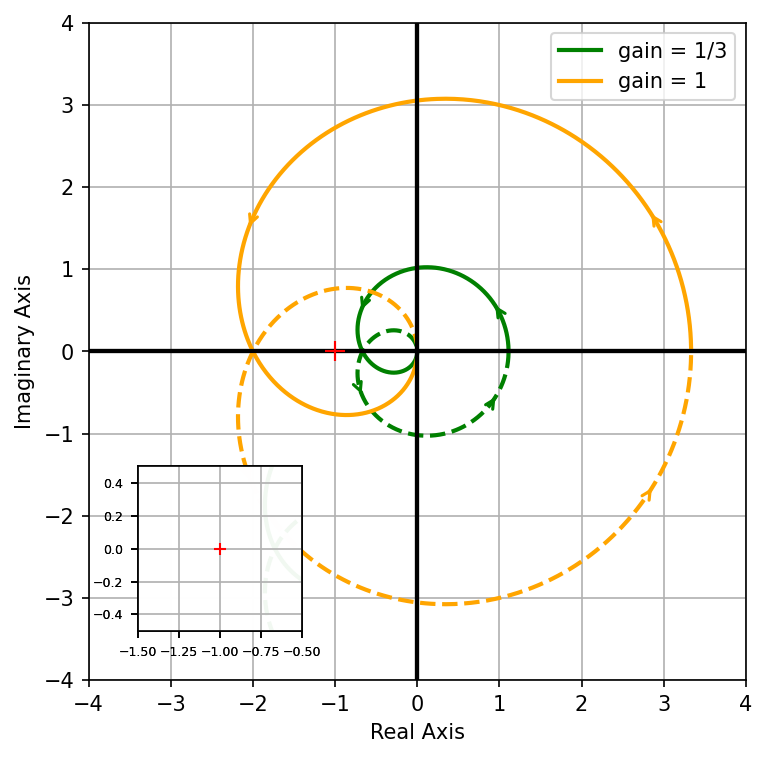

In [192]:
from matplotlib.lines import Line2D
RR = 0.25

def new_nyquist(w, G, ax=ax, color='blue', scale = 4, label = None, n_arrows=2):
    Gfreq  = G(1j*w)
    Re  = Gfreq.real
    Im  = Gfreq.imag

    # main axis Nyquist
    ax.plot(Re,  Im,  color=color,  label="gain = 1")
    ax.plot(Re,  -Im, color=color, ls='--')

    ax.axhline(0, color='k')
    ax.axvline(0, color='k')

    ax.set_aspect('equal')
    ax.set_xlim([-scale, scale])
    ax.set_ylim([-scale, scale])
    ax.set_xlabel("Real Axis")
    ax.set_ylabel("Imaginary Axis")

    add_arrows_to_line(ax, Re, Im, n_arrows=n_arrows, arrowstyle='->', color=color)
    add_arrows_to_line(ax, Re, -Im, n_arrows=n_arrows, arrowstyle='<-', color=color)

    # inset axes
    inset_ax = ax.inset_axes([.075, .075, .25, .25], transform=ax.transAxes)

    # inset plotting
    inset_ax.plot(Re,  Im,  color=color)
    inset_ax.plot(Re,  -Im, color=color, ls='--')

    # highlight −1 point
    inset_ax.plot([-1], [0], 'r+')
    ax.plot([-1], [0], 'r+',ms=10)

    # formatting inset
    inset_ax.set_xlim(-1.5, -0.5)
    inset_ax.set_ylim(-0.5, 0.5)
    inset_ax.patch.set_facecolor((1,1,1,0.95))
    inset_ax.tick_params(labelsize=6)

# add main legend
custom_lines = [
    Line2D([0],[0],color='green',lw=2),
    Line2D([0],[0],color='orange',lw=2),
]

fig, ax = plt.subplots(1,figsize=(5,5),dpi=150,constrained_layout=True)
new_nyquist(w, G/np.array(3), ax=ax, color='green', n_arrows=2)
ax.legend(custom_lines, ['gain = 1/3'])
plt.savefig("./figs/L20_fig3.pdf", dpi=300)

new_nyquist(w, G, ax=ax, color='orange', n_arrows=2)
ax.legend(custom_lines, ['gain = 1/3','gain = 1'])
plt.savefig("./figs/L20_fig3a.pdf", dpi=300)
plt.show()
 

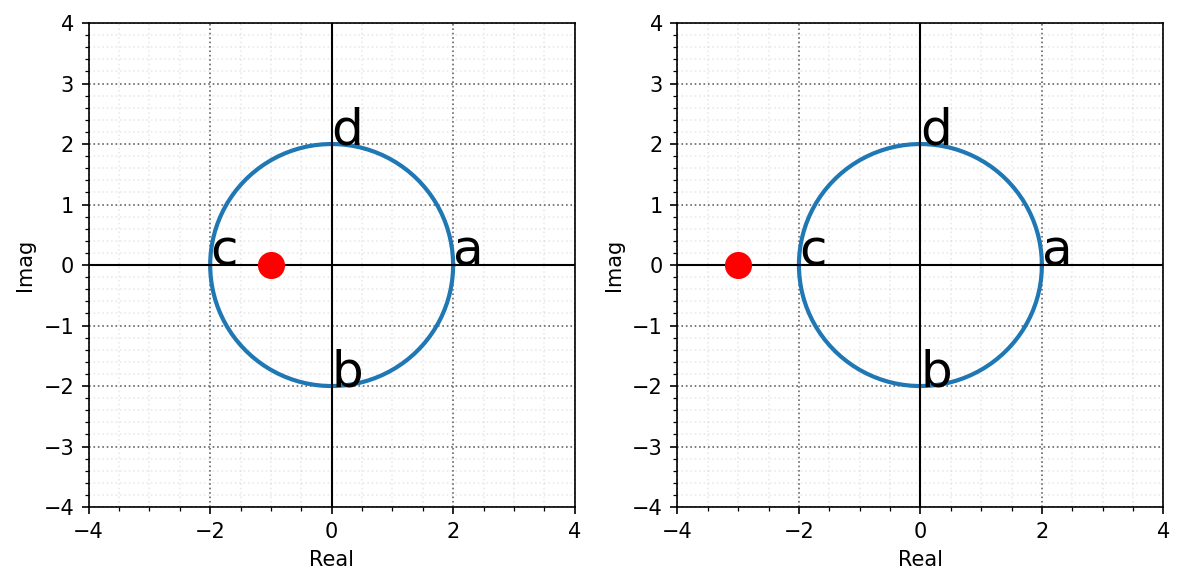

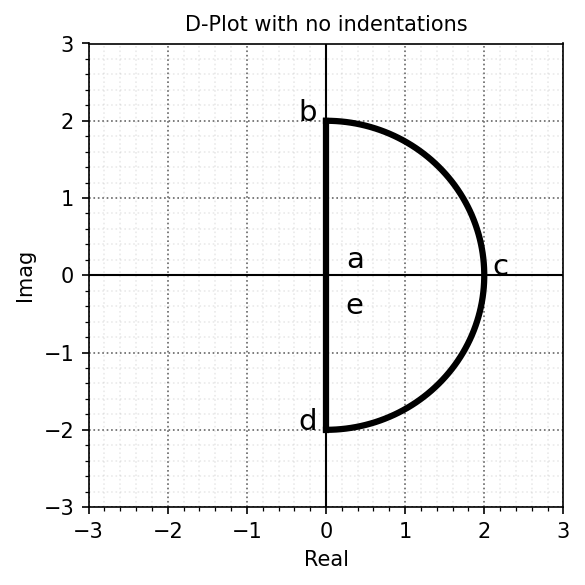

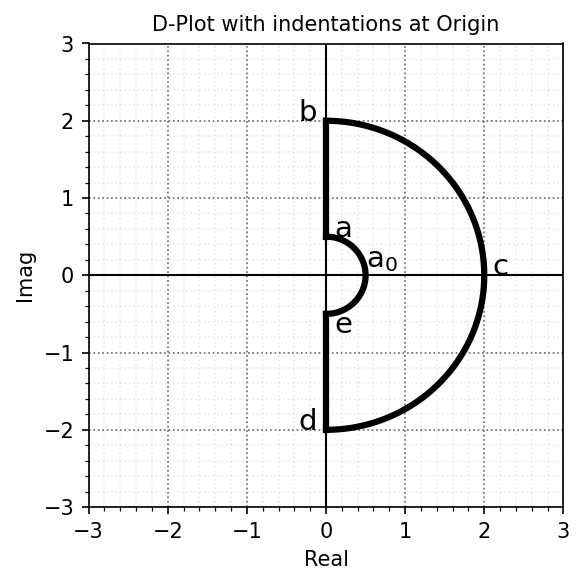

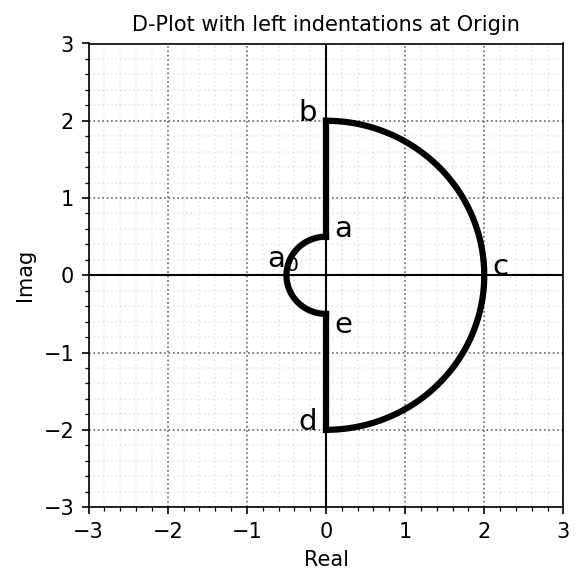

In [193]:
r = 2 #figure size
fig, (c1, c2) = plt.subplots(ncols=2, figsize=(8, 4))
an = np.linspace(0, 2 * np.pi, 100) 
c1.plot(r * np.cos(an), r * np.sin(an))
c2.plot(r * np.cos(an), r * np.sin(an))
c1.set_xlim((-4,4))
c2.set_xlim((-4,4))
c1.set_ylim((-4,4))
c2.set_ylim((-4,4))
bm.nicegrid(c1)
bm.nicegrid(c2)
c1.plot(-1,0,'ro',ms=12)
c2.plot(-3,0,'ro',ms=12)
c1.text(r,0,'a',fontsize=24) 
c1.text(0,-r,'b',fontsize=24) 
c1.text(-r,0,'c',fontsize=24) 
c1.text(0,r,'d',fontsize=24) 
c2.text(r,0,'a',fontsize=24) 
c2.text(0,-r,'b',fontsize=24) 
c2.text(-r,0,'c',fontsize=24) 
c2.text(0,r,'d',fontsize=24) 
c1.set_xlabel('Real')
c2.set_xlabel('Real')
c1.set_ylabel('Imag')
c2.set_ylabel('Imag')
plt.savefig("./figs/L18_circ.pdf", dpi=300)
plt.show()

r = 2
an = np.linspace(np.pi/2, -np.pi/2, 100) 
fig, (c3) = plt.subplots(ncols=1, figsize=(4, 4))
c3.plot(r * np.cos(an), r * np.sin(an),'k',lw=3)
c3.plot([0,0],[-r,r],'k',lw=3)
c3.set_xlim((-3,3))
c3.set_ylim((-3,3))
bm.nicegrid(c3)
c3.text(.25,0.1,'a',fontsize=14) 
c3.text(.250,-0.5,'e',fontsize=14) 
c3.text(-.35,-r,'d',fontsize=14) 
c3.text(r+.1,0,'c',fontsize=14) 
c3.text(-.35,r,'b',fontsize=14) 
c3.set_xlabel('Real')
c3.set_ylabel('Imag')
c3.set_title('D-Plot with no indentations')
plt.savefig("./figs/L19_circ2.pdf", dpi=300)
plt.show()

RR = 0.5
r = 2
an = np.linspace(np.pi/2, -np.pi/2, 100) 
fig, (c3) = plt.subplots(ncols=1, figsize=(4, 4))
c3.plot(r * np.cos(an), r * np.sin(an),'k',lw=3)
c3.plot(RR * np.cos(an), RR * np.sin(an),'k',lw=3)
c3.plot([0,0],[-r,-RR],'k',lw=3)
c3.plot([0,0],[RR,r],'k',lw=3)
c3.set_xlim((-3,3))
c3.set_ylim((-3,3))
bm.nicegrid(c3)
c3.text(0.1,RR,'a',fontsize=14) 
c3.text(RR,0.1,r'a$_0$',fontsize=14) 
c3.text(.1,-RR-.25,'e',fontsize=14) 
c3.text(-.35,-r,'d',fontsize=14) 
c3.text(r+.1,0,'c',fontsize=14) 
c3.text(-.35,r,'b',fontsize=14) 
c3.set_xlabel('Real')
c3.set_ylabel('Imag')
c3.set_title('D-Plot with indentations at Origin')
plt.savefig("./figs/L19_circ3.pdf", dpi=300)
plt.show()

fig, (c3) = plt.subplots(ncols=1, figsize=(4, 4))
c3.plot(r * np.cos(an), r * np.sin(an),'k',lw=3)
c3.plot(-RR * np.cos(an), RR * np.sin(an),'k',lw=3)
c3.plot([0,0],[-r,-RR],'k',lw=3)
c3.plot([0,0],[RR,r],'k',lw=3)
c3.set_xlim((-3,3))
c3.set_ylim((-3,3))
bm.nicegrid(c3)
c3.text(0.1,RR,'a',fontsize=14) 
c3.text(-RR-.25,0.1,r'a$_0$',fontsize=14) 
c3.text(.1,-RR-.25,'e',fontsize=14) 
c3.text(-.35,-r,'d',fontsize=14) 
c3.text(r+.1,0,'c',fontsize=14) 
c3.text(-.35,r,'b',fontsize=14) 
c3.set_xlabel('Real')
c3.set_ylabel('Imag')
c3.set_title('D-Plot with left indentations at Origin')
plt.savefig("./figs/L19_circ4.pdf", dpi=300)
plt.show()

## <a id='toc1_3_'></a>[Side by Side Nyquist](#toc0_)

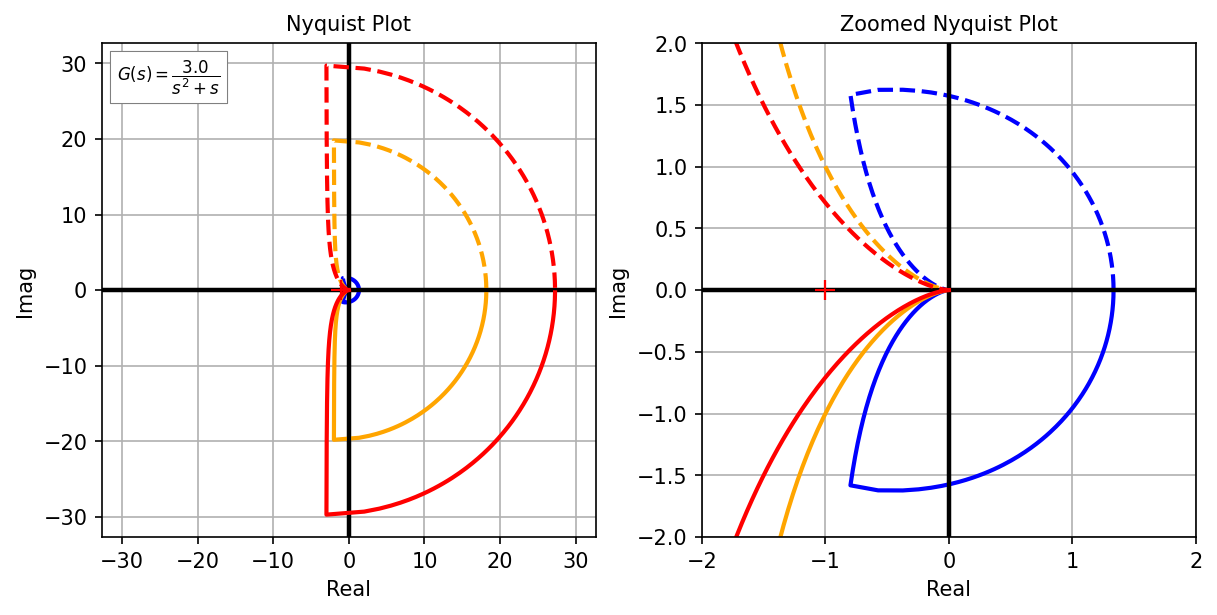

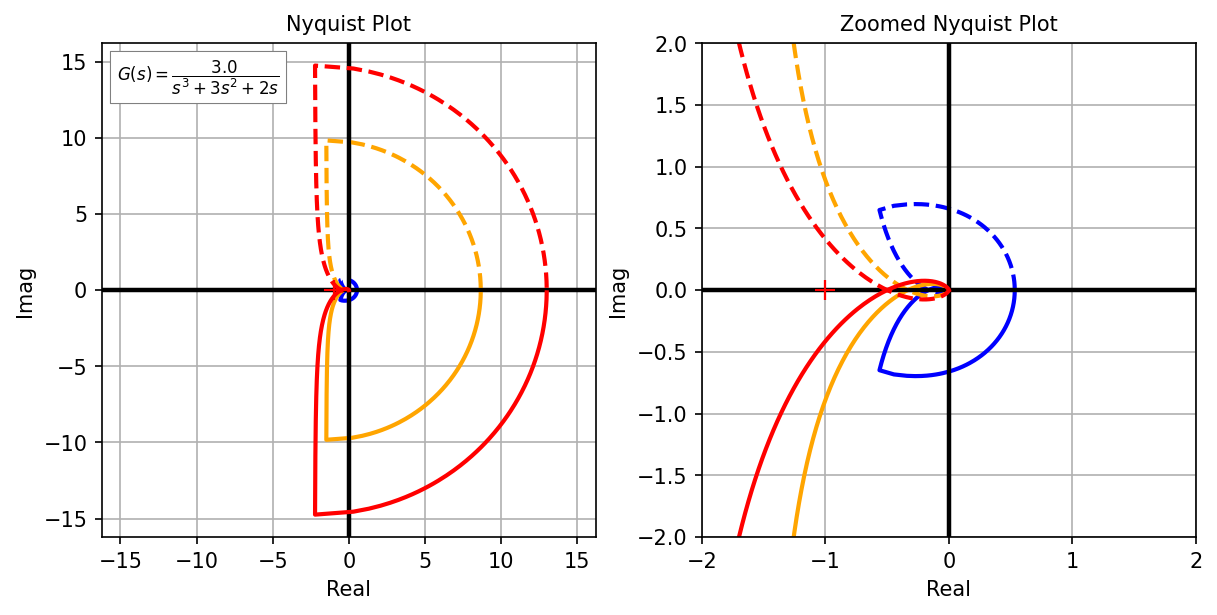

In [194]:
def Nyquist_side_by_side(G = None, resp = None, ax = None, RR = 0.1, w = np.logspace(-3,3,1000),col='b'):
    if resp is None:    
        if G is None:
            print("Nothing to do")
            return
        resp = ct.nyquist_response(G,w,indent_direction='right',indent_radius=RR,indent_points=100)
    
    if ax is None:
        fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
        return_flag = True
    else:
        return_flag = False

    maxsize = 1.1*max(np.max(np.abs(resp.response.real)), np.max(np.abs(resp.response.imag)))
    for ii in range(2):
        ax[ii].set_aspect('equal')
        ax[ii].axhline(y=0,ls='-',c='k')
        ax[ii].axvline(x=0,ls='-',c='k')
    
        ax[ii].plot(resp.response.real, resp.response.imag, color=col)
        ax[ii].plot(resp.response.real, -resp.response.imag, color=col,ls='--')
        ax[ii].plot(-1, 0, 'r+',ms=10)
        ax[ii].set_xlabel('Real')
        ax[ii].set_ylabel('Imag')
    ax[0].set_xlim([-maxsize,maxsize])
    ax[0].set_ylim([-maxsize,maxsize])
    ax[1].set_xlim([-2,2])
    ax[1].set_ylim([-2,2])
    ax[0].set_title('Nyquist Plot')
    ax[1].set_title('Zoomed Nyquist Plot')

    latex_G = r"$G(s) ="+cm.tf_to_latex(G)+"$"
    location = 'upper left'
    anchored_text = AnchoredText(latex_G, loc=location, prop=dict(size=8), frameon=True)
    anchored_text.patch.set_facecolor('white')
    anchored_text.patch.set_edgecolor('gray')
    anchored_text.patch.set_linewidth(0.5)
    ax[0].add_artist(anchored_text)
    
    return ax

G = ct.tf(1,[1,1,0])
ax1 = Nyquist_side_by_side(G = G, RR = RR)
ax2 = Nyquist_side_by_side(G = 2*G, ax=ax1, col='orange')
ax3 = Nyquist_side_by_side(G = 3*G, ax=ax2, col='red')

G = ct.tf(1,[1,1,0])*ct.tf(1,[1,2])
ax1 = Nyquist_side_by_side(G = G, RR = RR)
ax2 = Nyquist_side_by_side(G = 2*G, ax=ax1, col='orange')
ax3 = Nyquist_side_by_side(G = 3*G, ax=ax2, col='red')


In [195]:
G1 = ct.tf(1,[1,1,0])
print(f"Initial Angle {np.angle(G1(.0001j))*180/np.pi:>8.2f}")
print(f"Final Angle   {np.angle(G1(1000j))*180/np.pi:>8.2f}")

G2 = ct.tf(1,[1,1,0])*ct.tf(1,[1,2])
print(f"Initial Angle {np.angle(G2(.0001j))*180/np.pi:>8.2f}")
print(f"Final Angle   {np.angle(G2(1000j))*180/np.pi:>8.2f}")


Initial Angle   -90.01
Final Angle    -179.94
Initial Angle   -90.01
Final Angle      90.17


## <a id='toc1_2_'></a>[Example 20-4](#toc0_)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

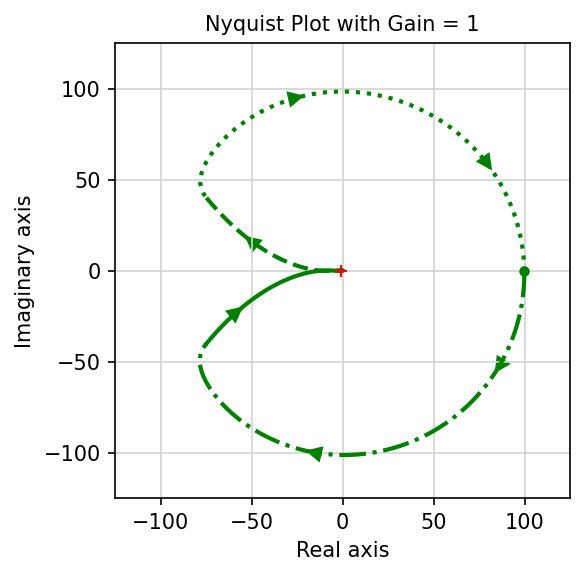

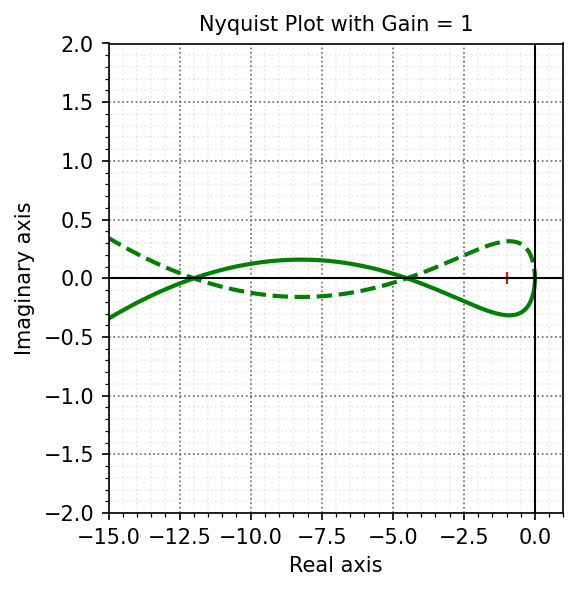

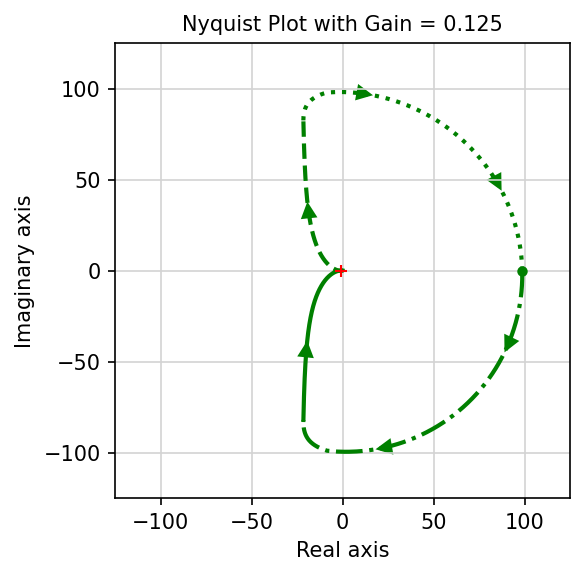

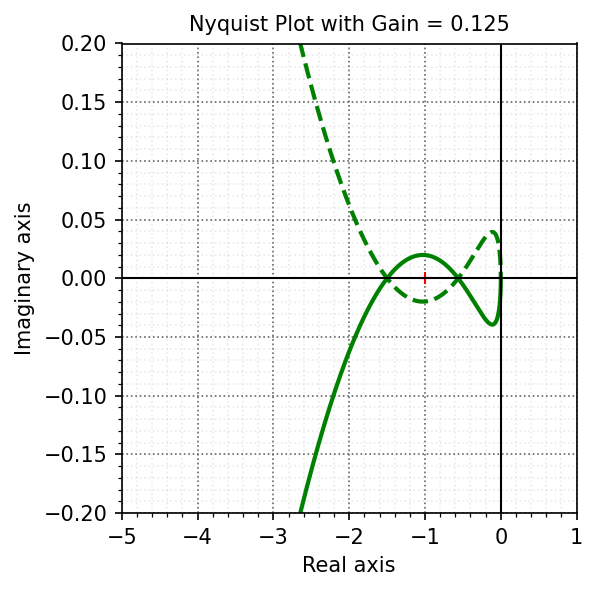

In [196]:
#20-4
G = 3*ct.tf([1],[1, 0])*ct.tf([1,6],[1, 1])**2 
display(cm.show_tf_latex(G))

w=np.append(0,np.logspace(-3,3,5000))
RR = 0.05

gain = 1
fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
Gcl1 = ct.feedback(gain*G,1) 

resp = cm.nyquist(gain*G,w,indent_direction='right',indent_radius=RR,indent_points=100,color='g' )
ax.set_aspect('equal')
ax.set_title(f'Nyquist Plot with Gain = '+str(gain))
plt.xlim([-125,125])
plt.ylim([-125,125])
plt.savefig("./figs/L18_circ2a.pdf", dpi=300)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = cm.nyquist(gain*G,w,indent_direction='right',indent_radius=RR,indent_points=100,color='g' )
ax.set_title(f'Nyquist Plot with Gain = '+str(gain))
plt.xlim([-15,1])
plt.ylim([-2,2])
bm.nicegrid(ax)
plt.savefig("./figs/L18_circ2b.pdf", dpi=300)

#20-4
gain = 1/8
display(cm.show_tf_latex(gain*G))

w=np.append(0,np.logspace(-3,3,5000))
RR = 0.05

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
Gcl1 = ct.feedback(gain*G,1) 

resp = cm.nyquist(gain*G,w,indent_direction='right',indent_radius=RR,indent_points=100,color='g' )
ax.set_aspect('equal')
ax.set_title(f'Nyquist Plot with Gain = '+str(gain))
plt.xlim([-125,125])
plt.ylim([-125,125])
plt.savefig("./figs/L18_circ3a.pdf", dpi=300)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = cm.nyquist(gain*G,w,indent_direction='right',indent_radius=RR,indent_points=100,color='g' )
ax.set_title(f'Nyquist Plot with Gain = '+str(gain))
plt.xlim([-5,1])
plt.ylim([-.2,.2])
bm.nicegrid(ax)
plt.savefig("./figs/L18_circ3b.pdf", dpi=300)


#20-4
gain = 1/8
G = ct.tf([3],[1, 0])*ct.tf([1,6],[1, 1])**2
w=np.append(0,np.logspace(-3,3,1000))
RR = 0.1

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
Gcl1 = ct.feedback(G,1) 

kwargs = {'color':'g'}
resp = ct.nyquist_response(gain*G,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,title='Nyquist Plot with Gain = '+str(gain))
ax.set_aspect('equal')
plt.xlim([-100,100])
plt.ylim([-100,100])
plt.savefig("./figs/L18_circ3a.pdf", dpi=300)

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
kwargs = {'color':'g'}
resp = ct.nyquist_response(gain*G,w,indent_direction='right',indent_radius=RR,indent_points=100)
ct.nyquist_plot(resp,**kwargs,title='Nyquist Plot with Gain = '+str(gain))
plt.xlim([-5,1])
plt.ylim([-.2,.2])
bm.nicegrid(ax)
plt.savefig("./figs/L18_circ3b.pdf", dpi=300)


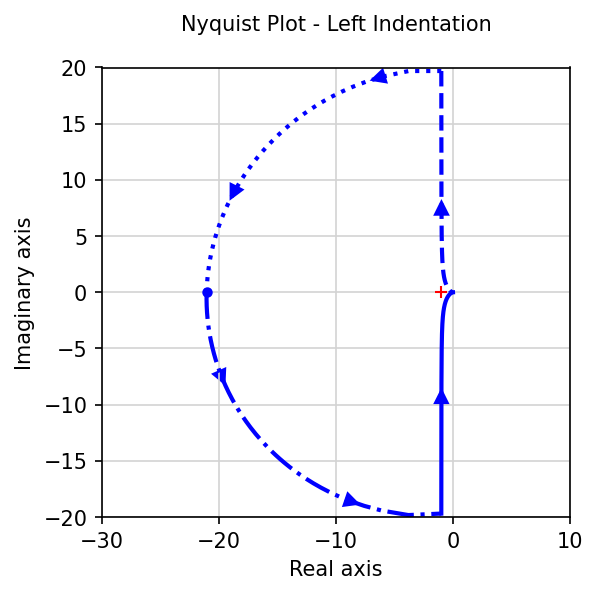

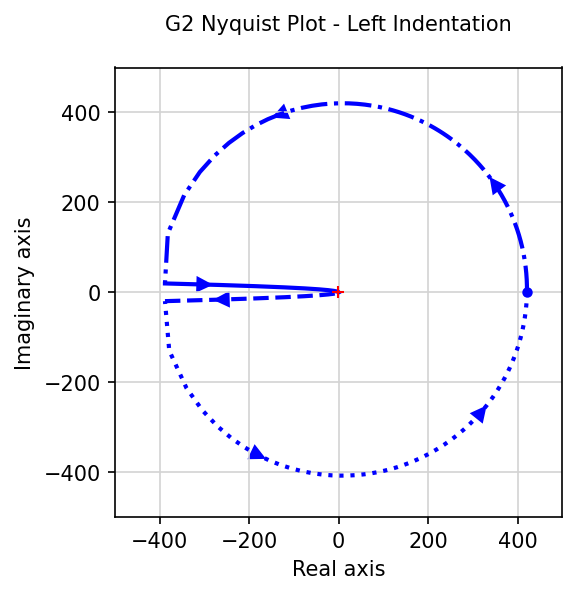

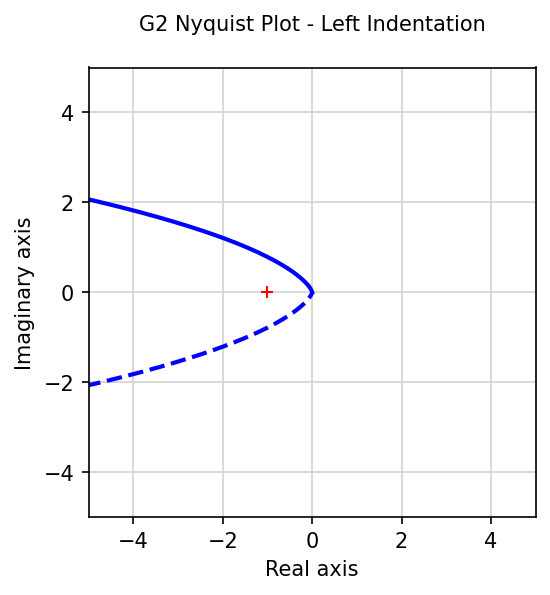

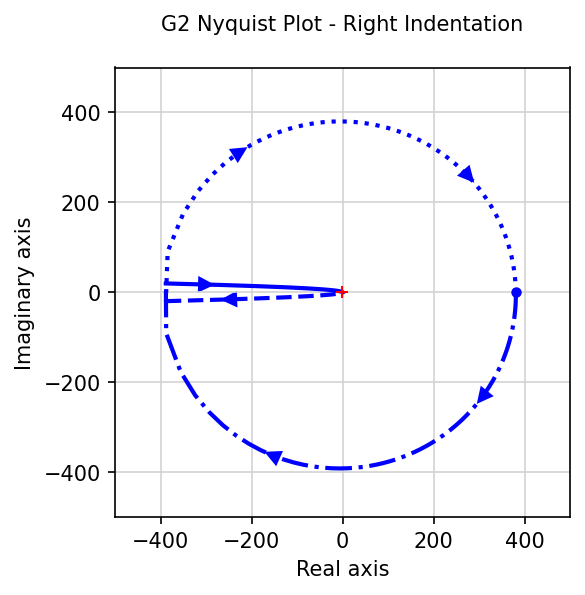

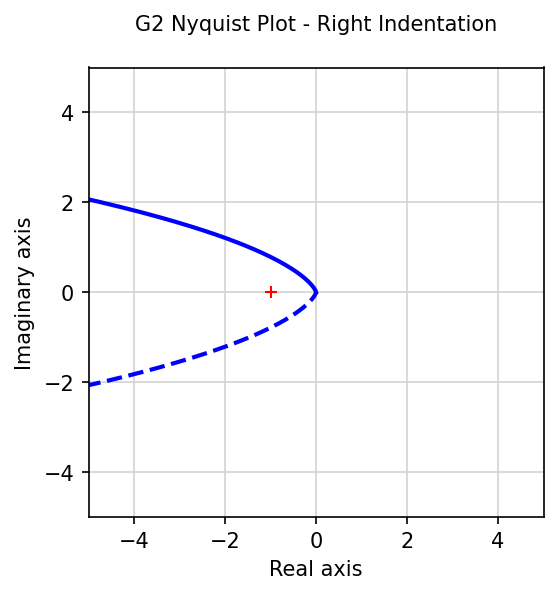

In [197]:
w = np.logspace(-6, 4, 1000)
#G = zpk([], [0, -2, -3], gain=100)
G1 = ct.tf([1],[1, 1]) * ct.tf([1],[1, 0])
G2 = ct.tf([1],[1, 1]) * ct.tf([1],[1, 0])**2

ct.set_defaults('nyquist',max_curve_magnitude = 100)
kwargs = {'color':'b'}

dir = 'left'
fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(G1,w,indent_points=100,indent_direction=dir,indent_radius=0.05)
ct.nyquist_plot(resp,**kwargs,title='Nyquist Plot - '+dir.capitalize()+' Indentation')
plt.xlim(-30,10)
plt.ylim(-20,20)

XX = 500
ct.set_defaults('nyquist',max_curve_magnitude = XX)
dir = 'left'
fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(G2,w,indent_points=100,indent_direction=dir,indent_radius=0.05)
ct.nyquist_plot(resp,**kwargs,title='G2 Nyquist Plot - '+dir.capitalize()+' Indentation')
plt.xlim(-XX,XX)
plt.ylim(-XX,XX)

XX = 5
fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(G2,w,indent_points=100,indent_direction=dir,indent_radius=0.05)
ct.nyquist_plot(resp,**kwargs,title='G2 Nyquist Plot - '+dir.capitalize()+' Indentation')
plt.xlim(-XX,XX)
plt.ylim(-XX,XX)

XX = 500
dir = 'right'
fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(G2,w,indent_points=100,indent_direction=dir,indent_radius=0.05)
ct.nyquist_plot(resp,**kwargs,title='G2 Nyquist Plot - '+dir.capitalize()+' Indentation')
plt.xlim(-XX,XX)
plt.ylim(-XX,XX)

XX = 5
dir = 'right'
fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(G2,w,indent_points=100,indent_direction=dir,indent_radius=0.05)
ct.nyquist_plot(resp,**kwargs,title='G2 Nyquist Plot - '+dir.capitalize()+' Indentation')
plt.xlim(-XX,XX)
plt.ylim(-XX,XX)

plt.show()

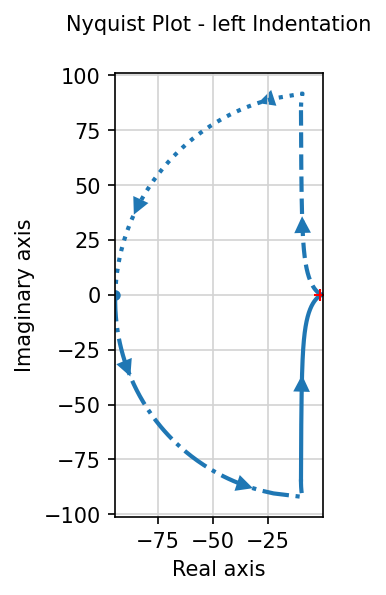

99.99999999999999

In [198]:
#from platform import python_version
#print("Running Python:",python_version())
#! pip list | grep control
#w = np.logspace(-6, 4, 1000)

from control import nyquist_plot, zpk, nyquist_response, tf
import matplotlib.pyplot as plt
import numpy as np
import control as ct
RR = 0.1
ct.set_defaults('nyquist',max_curve_magnitude = 1/RR**2)

G2 = 10*ct.tf([1],[1, 1]) * ct.tf([1],[1, 0])**1

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = nyquist_response(G2,indent_points=100,indent_direction='left',indent_radius=RR)
resp.plot(title='Nyquist Plot - left Indentation')
#plt.xlim(-2.5/RR,2.5/RR)
#plt.ylim(-2.5/RR,2.5/RR)
#plt.xlim(-4.5/RR,4.5/RR)
#plt.ylim(-4.5/RR,4.5/RR)
ax.set_aspect('equal')
plt.show()
ct.defaults['nyquist.max_curve_magnitude']

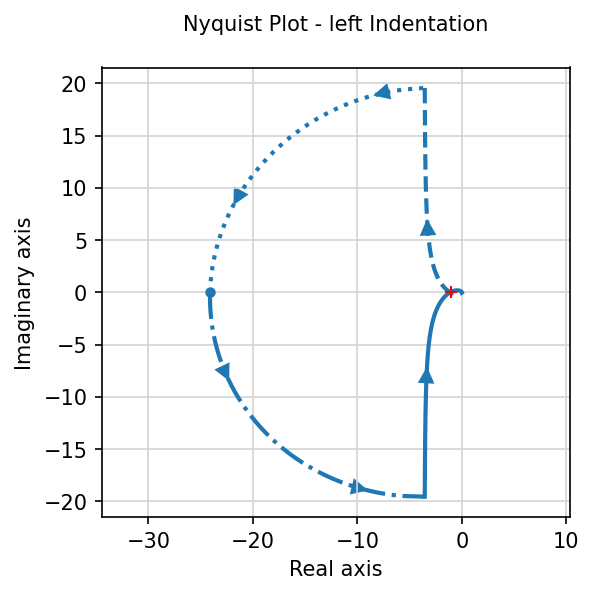

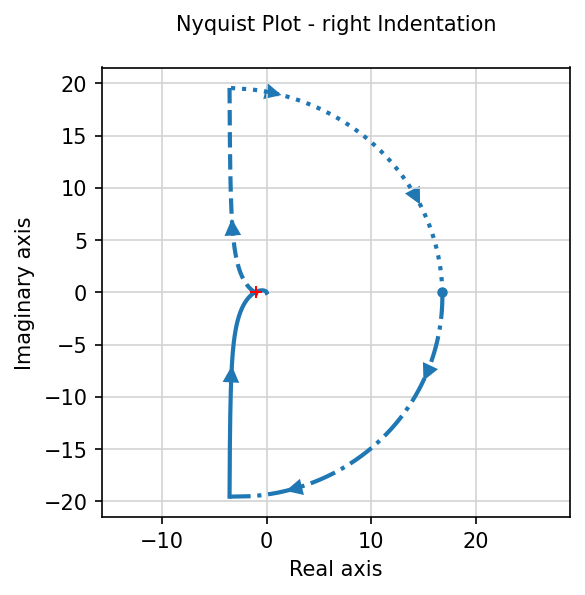

TransferFunction(
array([2]),
array([   1.000,    1.800,    1.000,    0.000]),
outputs=1, inputs=1)

In [199]:
from control import nyquist_plot, zpk, nyquist_response, tf
from matplotlib import pyplot as plt
import numpy as np
K = 2
num = 1
den = np.convolve([1, 0], [1, 2 * 0.9 * 1, 1])
sys1 = ct.tf(num,den)
sys2 = ct.tf(K*num,den)

import control as ct

RR = 0.1
fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(sys2,indent_direction='left',indent_radius=RR)
resp.plot(title='Nyquist Plot - left Indentation')
plt.axis([-2.5/RR,2.5/RR,-2.5/RR,2.5/RR])
plt.axis('equal')
plt.show()

fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150)
resp = ct.nyquist_response(sys2,indent_direction='right',indent_radius=RR)
resp.plot(title='Nyquist Plot - right Indentation')
plt.axis([-2.5/RR,2.5/RR,-2.5/RR,2.5/RR])
plt.axis('equal')
plt.show()
sys2


(-5.0, 5.0)

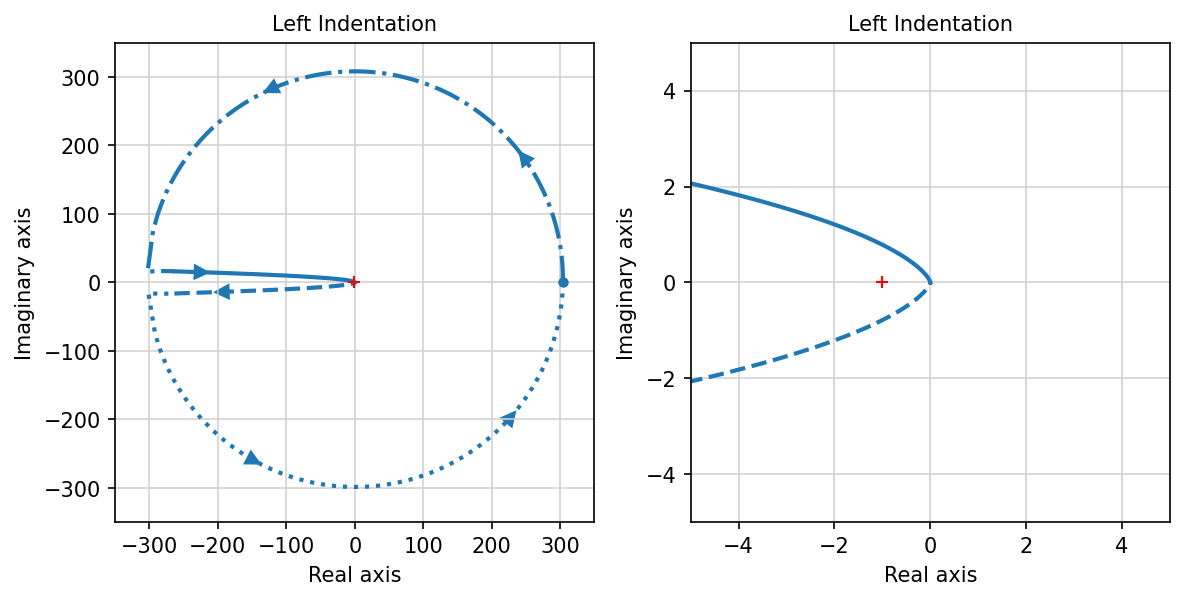

In [200]:
G = ct.tf([1], [1, 1]) * ct.tf([1], [1, 0])**2

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150)

max_mag = 350
resp = ct.nyquist_response(G, indent_direction='left', indent_radius=0.05)
cplt = resp.plot(max_curve_magnitude=max_mag*0.9,ax=ax[0])
ax[0].set_title('Left Indentation')
ax[0].set_aspect('equal')
ax[0].set_ylim(-max_mag,max_mag)
ax[0].set_xlim(-max_mag,max_mag)

max_mag = 350
resp = ct.nyquist_response(G, indent_direction='left', indent_radius=0.05)
cplt = resp.plot(max_curve_magnitude=max_mag*0.9,ax=ax[1])
ax[1].set_title('Left Indentation')
ax[1].set_aspect('equal')
ax[1].set_ylim(-5,5)
ax[1].set_xlim(-5,5)

#cplt = resp.plot(max_curve_magnitude=10,ax=ax[1])
